# Retail Sales Data Analysis & Customer Segmentation

## Level 4: Exploratory Data Analysis (EDA)

### Objective

The objective of this phase is to explore sales performance, customer purchasing behavior, product performance, revenue trends, and geographic distribution through statistical analysis and data visualization.

This phase aims to transform transactional data into actionable business insights by identifying key revenue drivers, customer patterns, seasonal trends, and growth opportunities.

By the end of this phase, a comprehensive understanding of business performance and customer behavior will be established, providing a strong foundation for Pareto Analysis, RFM Analysis, Customer Segmentation, and Customer Lifetime Value (CLV) evaluation.

---

### Dataset Loading & Validation

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv("../outputs/feature_engineered_retail.csv")
print("Data Loaded")

Data Loaded


## Section 1: Business Overview KPIs

### Total Revenue Generated

In [4]:
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


### Total Orders

Analyzing the total number of orders helps measure transaction activity and customer engagement across the business.

In [5]:
total_orders = df["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 18,532


### Total Customers

In [6]:
total_customers = df["CustomerID"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 4,338


### Total Products

In [7]:
total_products = df["StockCode"].nunique()

print(f"Total Products: {total_products:,}")

Total Products: 3,665


### Average Order Value (AOV)

Average Order Value measures the average revenue generated per order and is a key indicator of customer spending behavior.

In [8]:
aov = df["Revenue"].sum() / df["InvoiceNo"].nunique()

print(f"Average Order Value: £{aov:,.2f}")

Average Order Value: £479.56


## Section 2: Revenue & Order Trend Analysis

### Monthly Revenue Trend

Analyzing monthly revenue helps identify seasonal patterns, peak sales periods, and fluctuations in business performance throughout the year.

In [9]:
monthly_revenue = (
    df.groupby("InvoiceMonthYear")["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue.head()

,InvoiceMonthYear,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331


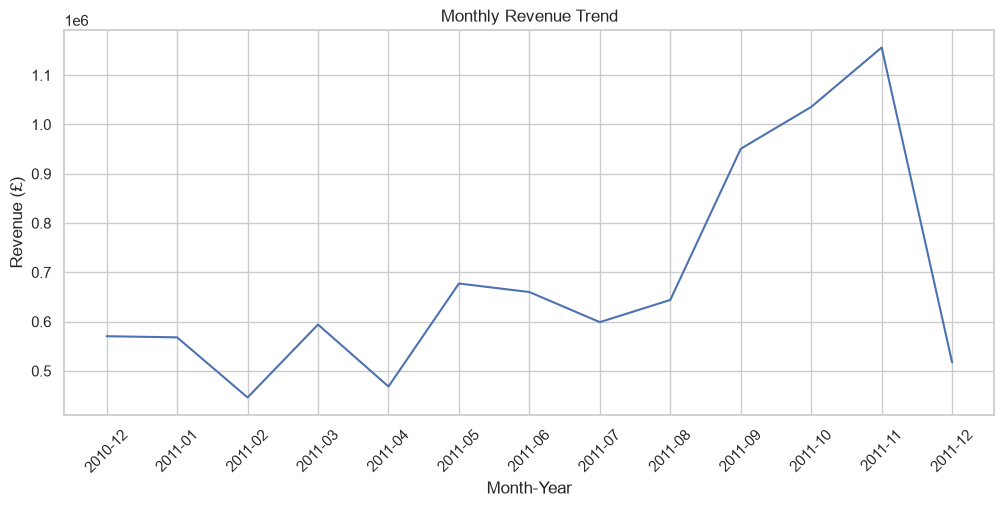

In [10]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_revenue,
    x="InvoiceMonthYear",
    y="Revenue"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

- Monthly revenue fluctuates throughout the analysis period.
- Revenue remains relatively stable between January and August 2011.
- A sharp increase in revenue is observed between August and September 2011.
- Revenue continues to increase during October and reaches its highest value in November 2011.
- November 2011 records the highest monthly revenue in the dataset.
- December 2011 records significantly lower revenue than the preceding months.

---

### Monthly Order Trend

Analyzing order volume over time helps determine whether revenue growth is driven by an increase in customer purchases or changes in spending behavior.

In [11]:
monthly_orders = (
    df.groupby("InvoiceMonthYear")["InvoiceNo"]
      .nunique()
      .reset_index(name="Orders")
)

monthly_orders.head()

,InvoiceMonthYear,Orders
0,2010-12,1400
1,2011-01,987
2,2011-02,997
3,2011-03,1321
4,2011-04,1149


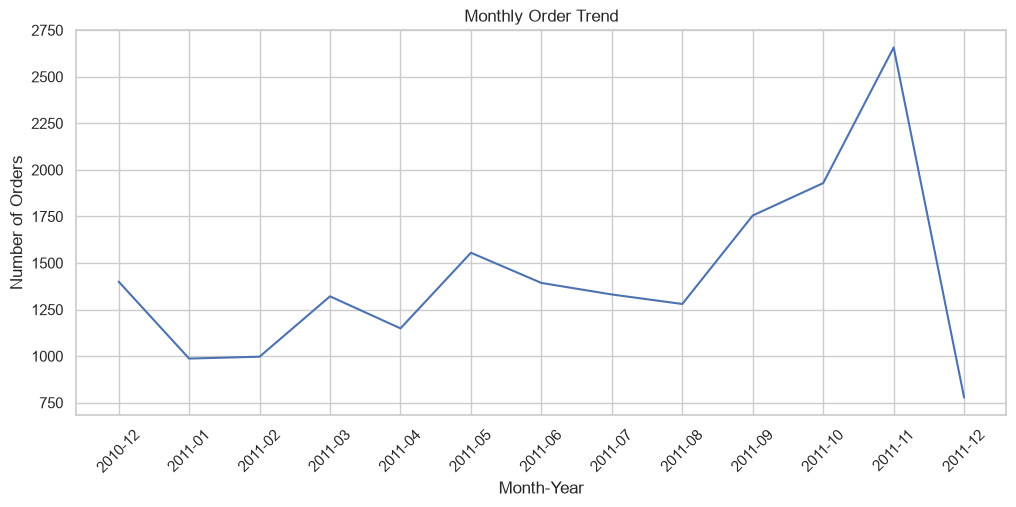

In [12]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_orders,
    x="InvoiceMonthYear",
    y="Orders"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month-Year")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

- Monthly order volume varies across the analysis period.
- Order activity remains relatively consistent during the first eight months of 2011.
- Orders increase substantially between August and September 2011.
- The highest number of orders is recorded in November 2011.
- Monthly order volume follows a pattern similar to monthly revenue.
- December 2011 records the lowest order volume among the final months shown.

---

### Quarterly Revenue Trend

Quarterly analysis provides a broader view of business performance and helps identify long-term sales patterns across different periods of the year.

In [13]:
quarterly_revenue = (
    df.groupby("Quarter")["Revenue"]
      .sum()
      .reset_index()
)

quarterly_revenue

,Quarter,Revenue
0,1,1608267.990
1,2,1805775.531
2,3,2193704.143
3,4,3279461.230


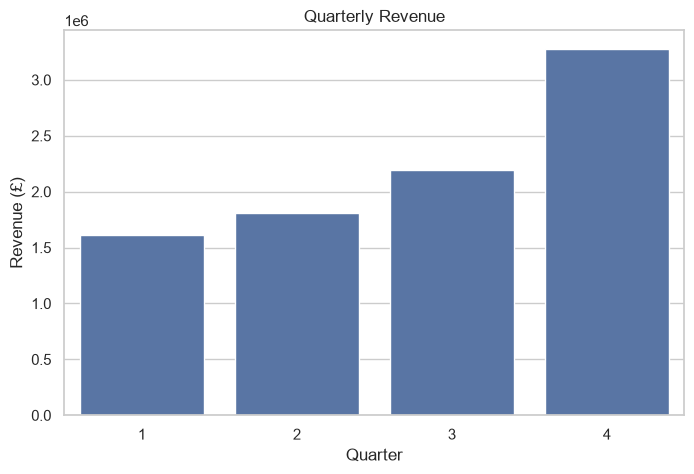

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=quarterly_revenue,
    x="Quarter",
    y="Revenue"
)

plt.title("Quarterly Revenue")
plt.xlabel("Quarter")
plt.ylabel("Revenue (£)")

plt.show()

- Revenue increases progressively from Quarter 1 to Quarter 4.
- Quarter 1 records the lowest total revenue.
- Quarter 4 records the highest total revenue.
- Quarter 4 contributes a substantially larger revenue amount compared to the other quarters.
- No quarter shows a decline compared to the preceding quarter.

---

### Revenue by Day of Week

Analyzing revenue by weekday helps identify customer purchasing behavior patterns and the days that contribute most to overall sales.

In [15]:
weekday_revenue = (
    df.groupby("DayOfWeek")["Revenue"]
      .sum()
      .reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
      .reset_index()
)

weekday_revenue

,DayOfWeek,Revenue
0,Monday,1363604.401
1,Tuesday,1697733.801
2,Wednesday,1584283.830
3,Thursday,1973015.730
4,Friday,1483080.811
5,Saturday,NaN
6,Sunday,785490.321


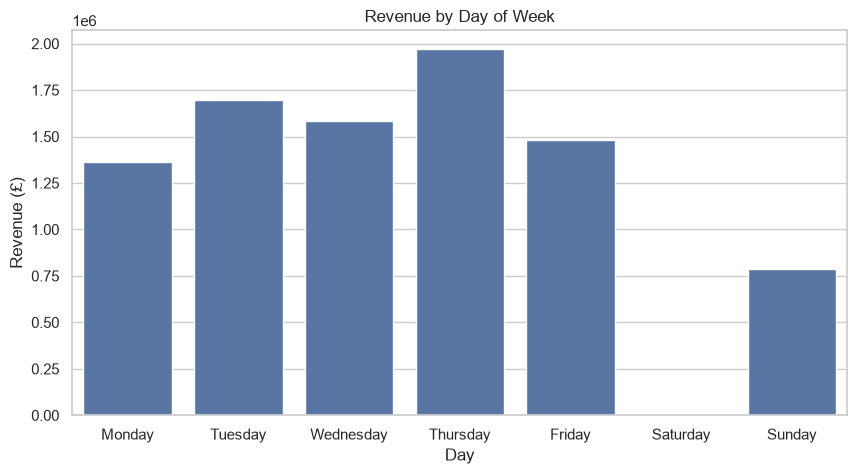

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_revenue,
    x="DayOfWeek",
    y="Revenue"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")

plt.show()

- Revenue varies across different days of the week.
- Thursday generates the highest revenue among all recorded days.
- Tuesday and Wednesday also contribute significant revenue.
- Sunday records the lowest revenue among days with transactions.
- No transactions are present for Saturday in the dataset.
- The absence of Saturday transactions appears to be a characteristic of the source dataset rather than a data processing issue.

---

## Section 3: Product Performance Analysis

### Top 10 Products by Revenue

Identifying the products that generate the highest revenue helps understand which items contribute most to business success.

In [17]:
top_products_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products_revenue

,Description,Revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68785.23
7,ASSORTED COLOUR BIRD ORNAMENT,56413.03
8,Manual,53419.93
9,RABBIT NIGHT LIGHT,51251.24


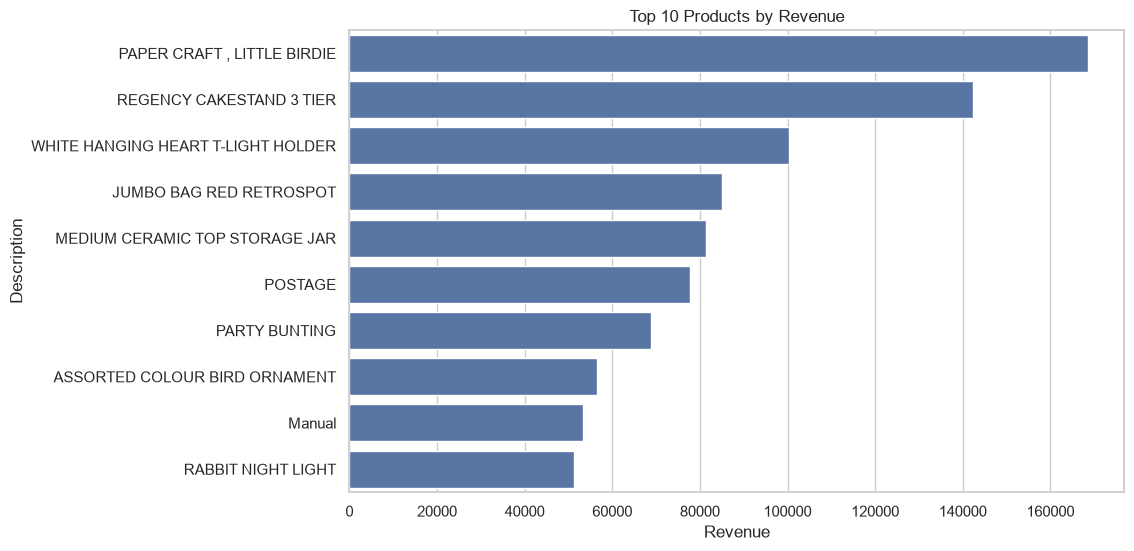

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")

plt.show()

- "PAPER CRAFT , LITTLE BIRDIE" generates the highest revenue among all products.
- The top-ranked product generates noticeably higher revenue than the remaining products.
- Revenue is concentrated among a relatively small number of products.
- Several products contribute more than £50,000 in revenue.
- The revenue difference between the highest and tenth-ranked product is substantial.

---

### Top 10 Products by Quantity Sold

Analyzing product sales volume helps identify the most frequently purchased items and customer preferences.

In [19]:
top_products_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products_quantity

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3,JUMBO BAG RED RETROSPOT,46078
4,WHITE HANGING HEART T-LIGHT HOLDER,36706
5,ASSORTED COLOUR BIRD ORNAMENT,35263
6,PACK OF 72 RETROSPOT CAKE CASES,33670
7,POPCORN HOLDER,30919
8,RABBIT NIGHT LIGHT,27153
9,MINI PAINT SET VINTAGE,26076


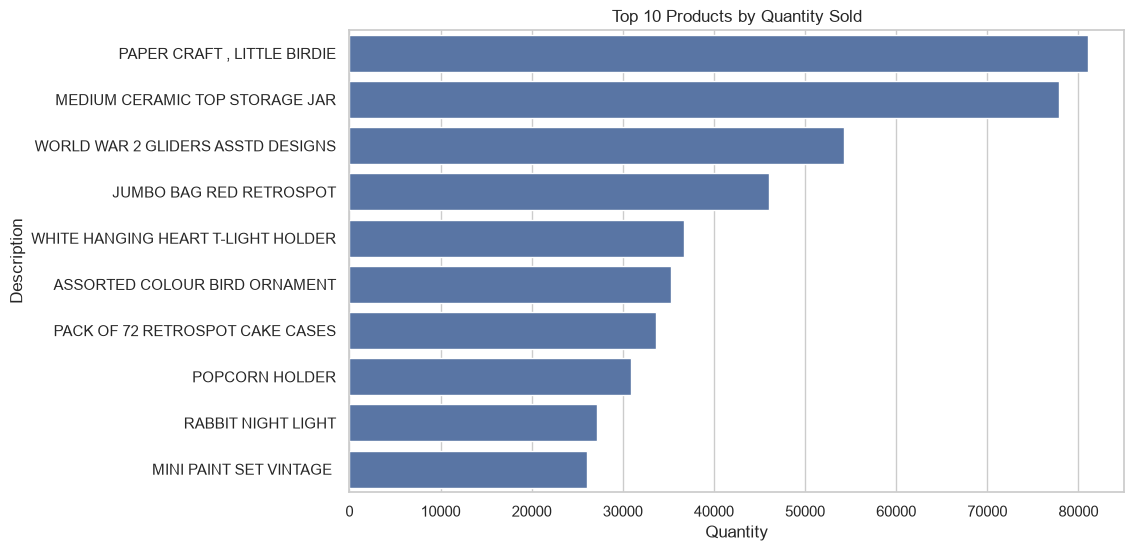

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_products_quantity,
    x="Quantity",
    y="Description"
)

plt.title("Top 10 Products by Quantity Sold")

plt.show()

- "PAPER CRAFT , LITTLE BIRDIE" records the highest quantity sold.
- The top-selling product exceeds 80,000 units sold.
- Product sales volume varies considerably across the top 10 products.
- Several products appear in both the quantity and revenue rankings.
- Sales volume is concentrated among a relatively small group of products.

---

## Section 4: Customer Analysis

### Top 10 Customers by Revenue

Identifying the highest-value customers helps understand which individuals contribute most significantly to business revenue.

This analysis supports customer retention strategies, loyalty programs, and customer relationship management initiatives.

In [21]:
top_customers_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_customers_revenue

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


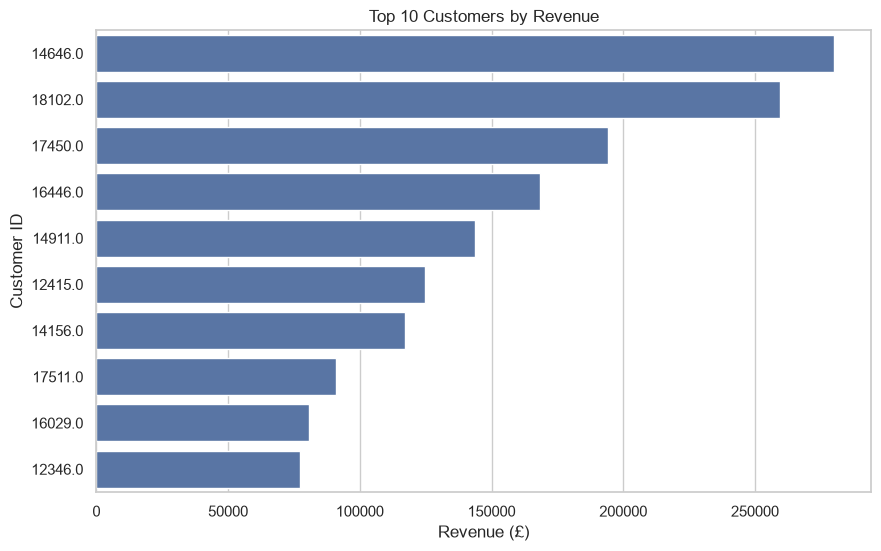

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers_revenue,
    x="Revenue",
    y=top_customers_revenue["CustomerID"].astype(str)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.show()

- Customer 14646 generates the highest revenue contribution.
- The highest-revenue customer contributes substantially more revenue than most customers in the dataset.
- Revenue among the top 10 customers ranges from approximately £77,000 to £280,000.
- A relatively small group of customers contributes a large amount of revenue.
- Revenue contribution varies significantly across the top customers.

---

### Top 10 Customers by Number of Orders

Analyzing purchase frequency helps identify highly engaged customers and recurring buyers.

Understanding customer ordering behavior supports retention planning and customer segmentation.

In [23]:
top_customers_orders = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Orders")
)

top_customers_orders

,CustomerID,Orders
0,12748.0,209
1,14911.0,201
2,17841.0,124
3,13089.0,97
4,14606.0,93
5,15311.0,91
6,12971.0,86
7,14646.0,73
8,16029.0,63
9,13408.0,62


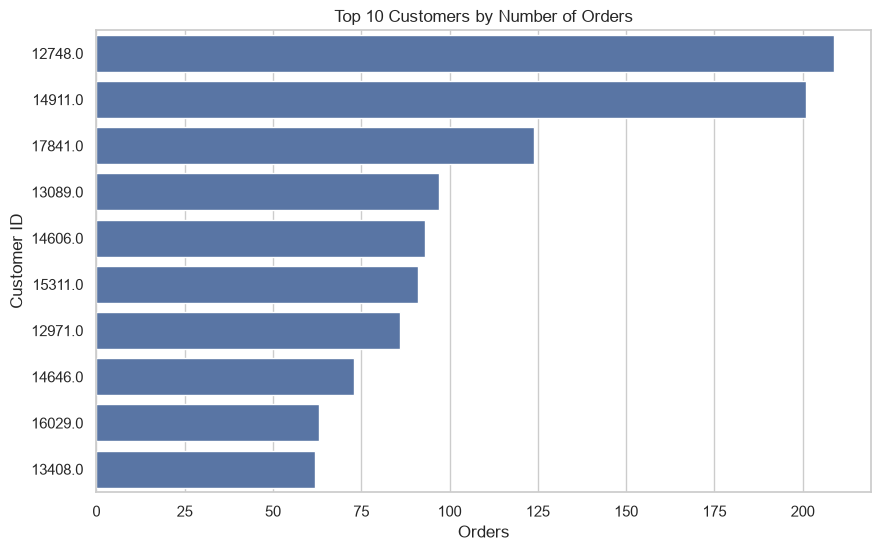

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers_orders,
    x="Orders",
    y=top_customers_orders["CustomerID"].astype(str)
)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Orders")
plt.ylabel("Customer ID")

plt.show()

- Customer 12748 places the highest number of orders.
- The top customer records more than 200 unique orders.
- Order frequency varies substantially across the top customers.
- Several customers place considerably more orders than the rest of the customer base.
- Customer purchasing activity is concentrated among a small number of highly active customers.

---


### Customer Revenue Distribution

Customer revenue distribution helps determine whether revenue is evenly distributed across customers or concentrated among a smaller group of high-value customers.

This analysis provides an initial indication of revenue concentration and customer value variation.

In [25]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
)

customer_revenue.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Revenue, dtype: float64

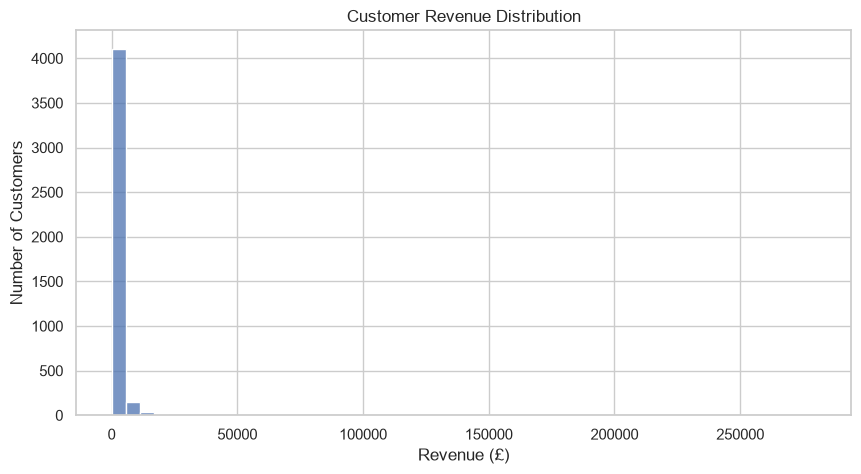

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_revenue,
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Customers")

plt.show()

- The customer revenue distribution is highly right-skewed.
- Most customers are concentrated within the lower revenue ranges.
- The number of customers decreases significantly as revenue increases.
- A small group of customers generates substantially higher revenue than the majority of customers.
- The distribution contains a long right tail, indicating the presence of high-revenue customers.
- Customer spending levels vary considerably across the customer base.

---

## Section 5: Geographic Analysis

## Top Countries by Revenue

Understanding revenue contribution by country helps identify the most valuable markets and regions driving business growth.

In [27]:
top_countries_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_countries_revenue

,Country,Revenue
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


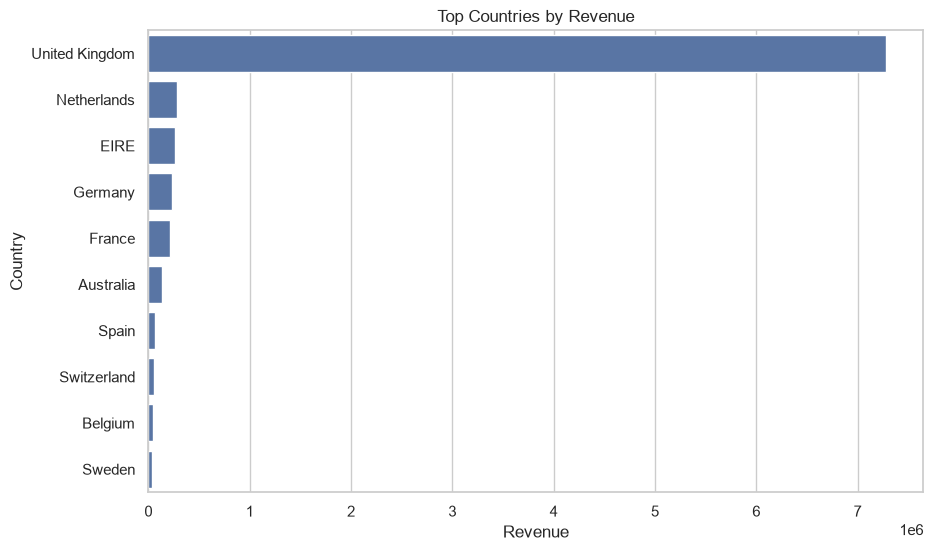

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_countries_revenue,
    x="Revenue",
    y="Country"
)

plt.title("Top Countries by Revenue")

plt.show()

- The United Kingdom generates the highest revenue among all countries.
- Revenue from the United Kingdom is substantially larger than every other country.
- The Netherlands, EIRE, Germany, and France are the leading international markets by revenue.
- Revenue contribution declines considerably after the top-ranked countries.
- Revenue is concentrated among a small number of countries.

---

### Top Countries by Orders

Analyzing order volume by country helps evaluate customer activity and market engagement across different geographic regions.

In [29]:
top_countries_orders = (
    df.groupby("Country")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Orders")
)

top_countries_orders

,Country,Orders
0,United Kingdom,16646
1,Germany,457
2,France,389
3,EIRE,260
4,Belgium,98
5,Netherlands,94
6,Spain,90
7,Portugal,57
8,Australia,57
9,Switzerland,51


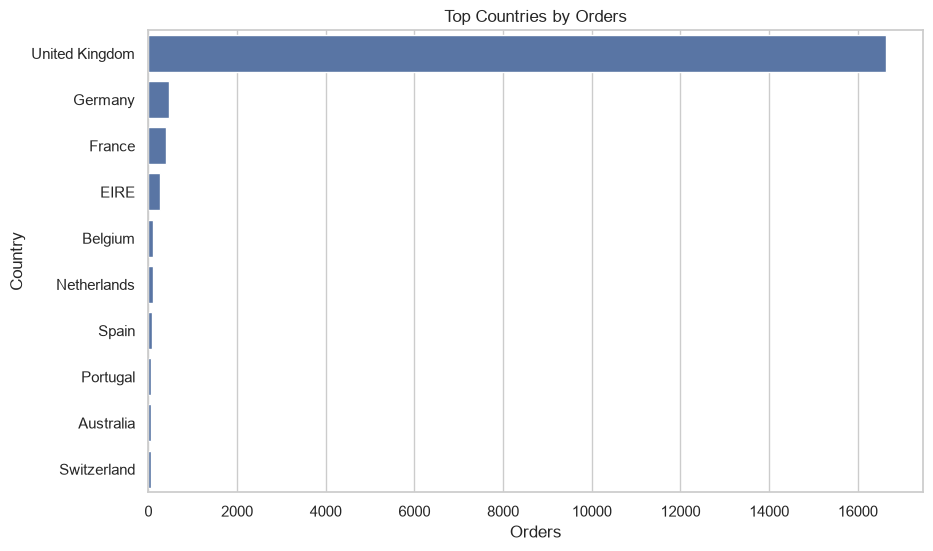

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_countries_orders,
    x="Orders",
    y="Country"
)

plt.title("Top Countries by Orders")

plt.show()

- The United Kingdom records the highest number of orders.
- Germany and France are the next largest countries by order volume.
- Order activity drops significantly after the United Kingdom.
- The top 10 countries account for a large share of total orders.
- Order volume is concentrated among a relatively small number of countries.

---

## Section 6: Revenue Concentration Analysis

### Revenue Contribution by Top Customers

Businesses often observe that a relatively small percentage of customers contribute a large share of revenue.

This analysis evaluates the revenue contribution of the highest-value customers and provides a foundation for Pareto Analysis.

In [31]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_10_customers_revenue = customer_revenue.head(10).sum()

remaining_customers_revenue = (
    customer_revenue.sum()
    - top_10_customers_revenue
)

revenue_contribution = pd.DataFrame({
    "Category": ["Top 10 Customers", "Remaining Customers"],
    "Revenue": [
        top_10_customers_revenue,
        remaining_customers_revenue
    ]
})

revenue_contribution

,Category,Revenue
0,Top 10 Customers,1537659.210
1,Remaining Customers,7349549.684


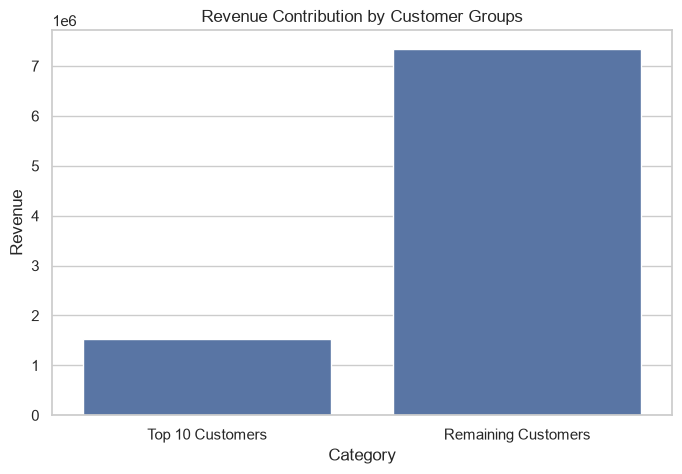

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_contribution,
    x="Category",
    y="Revenue"
)

plt.title("Revenue Contribution by Customer Groups")

plt.show()

- The top 10 customers generate approximately £1.54 million in revenue.
- The remaining customers generate approximately £7.35 million in revenue.
- Revenue contribution is not evenly distributed across the customer base.
- A small group of customers contributes a substantial portion of total revenue.
- Customer value varies considerably across the dataset.

---

### Summary

#### Exploratory Analysis Activities

The exploratory analysis examined business performance from multiple perspectives, including:

- Revenue Performance
- Order Activity
- Customer Analysis
- Product Performance
- Geographic Analysis
- Revenue Distribution
- Revenue Concentration Analysis

A total of 12 business-focused analyses were conducted to understand sales trends, customer behavior, and revenue drivers.

---

#### Key Business Insights

The analysis revealed several important patterns:

- The business generated approximately £8.89 million in total revenue.
- More than 18,500 orders were completed across 4,338 customers.
- Revenue and order activity peaked during November 2011.
- Quarter 4 generated the highest overall revenue contribution.
- Revenue generation is concentrated among a relatively small number of products and customers.
- The United Kingdom represents the dominant market in terms of both revenue and order volume.
- Customer spending distribution is highly uneven across the customer base.

These findings highlight important differences in customer value, product contribution, and market performance.

---

#### Business Impact

The exploratory analysis provided valuable insights into:

- Revenue Drivers
- Customer Purchasing Behavior
- Product Contribution
- Market Performance
- Revenue Concentration

These insights can support customer retention strategies, product planning, revenue optimization, and future customer segmentation initiatives.

---

#### Analysis Outcome

The EDA phase successfully transformed transactional data into actionable business intelligence by identifying trends, patterns, and concentration effects across customers, products, and markets.

The results establish a strong analytical foundation for customer value assessment and behavioral segmentation.

---

#### Conclusion

The Exploratory Data Analysis phase provided a comprehensive understanding of sales performance, customer behavior, product contribution, and revenue distribution. The insights generated during this phase will support advanced customer analytics and help guide data-driven business decision-making.

---

#### Next Step

**Level 5: RFM Analysis**

The next phase will focus on evaluating customer value using Recency, Frequency, and Monetary metrics to identify customer purchasing patterns and prepare the foundation for customer segmentation and Customer Lifetime Value (CLV) analysis.